In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
sns.set_theme(style="white")

In [2]:
rng = np.random.default_rng(42)

cohort_months = pd.date_range(
    start="2025-01-01",
    periods=7,
    freq="MS"
)

retention_curve = [1.00, 0.56, 0.42, 0.35, 0.31, 0.29, 0.28]

records = []
user_number = 1
order_number = 1

for cohort_month in cohort_months:
    cohort_size = int(rng.integers(600, 801))

    max_age = (
        (cohort_months[-1].year - cohort_month.year) * 12
        + cohort_months[-1].month
        - cohort_month.month
    )

    for _ in range(cohort_size):
        user_id = f"USER_{user_number:05d}"
        survival_draw = rng.random()

        for cohort_age in range(max_age + 1):
            is_active = (
                cohort_age == 0
                or survival_draw < retention_curve[cohort_age]
            )

            if is_active:
                transaction_month = (
                    cohort_month
                    + pd.DateOffset(months=cohort_age)
                )

                # Multiple orders create realistic repeated rows.
                number_of_orders = int(rng.integers(1, 4))

                for _ in range(number_of_orders):
                    records.append({
                        "order_id": f"ORDER_{order_number:06d}",
                        "user_id": user_id,
                        "transaction_date": (
                            transaction_month
                            + pd.Timedelta(days=int(rng.integers(0, 28)))
                        )
                    })
                    order_number += 1

        user_number += 1

transactions = pd.DataFrame(records)

print("Unique users:", transactions["user_id"].nunique())
print("Raw transaction rows:", len(transactions))
print(
    "Date range:",
    transactions["transaction_date"].min().date(),
    "to",
    transactions["transaction_date"].max().date()
)

transactions.head()

Unique users: 4808
Raw transaction rows: 21000
Date range: 2025-01-01 to 2025-07-28


,order_id,user_id,transaction_date
0,ORDER_000001,USER_00001,2025-01-13
1,ORDER_000002,USER_00001,2025-01-25
2,ORDER_000003,USER_00001,2025-01-03
3,ORDER_000004,USER_00001,2025-02-06
4,ORDER_000005,USER_00001,2025-02-03


In [3]:
transactions["transaction_month"] = (
    pd.to_datetime(transactions["transaction_date"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

# First active month becomes the user's acquisition month.
transactions["cohort_month"] = (
    transactions.groupby("user_id")["transaction_month"]
    .transform("min")
)

transactions["cohort_index"] = (
    (transactions["transaction_month"].dt.year
     - transactions["cohort_month"].dt.year) * 12
    + (transactions["transaction_month"].dt.month
       - transactions["cohort_month"].dt.month)
)

# Count each user once per active month.
monthly_activity = transactions.drop_duplicates(
    subset=["user_id", "transaction_month"]
).copy()

monthly_activity[
    ["user_id", "transaction_month", "cohort_month", "cohort_index"]
].head(10)

,user_id,transaction_month,cohort_month,cohort_index
0,USER_00001,2025-01-01,2025-01-01,0
3,USER_00001,2025-02-01,2025-01-01,1
6,USER_00002,2025-01-01,2025-01-01,0
9,USER_00003,2025-01-01,2025-01-01,0
10,USER_00003,2025-02-01,2025-01-01,1
12,USER_00004,2025-01-01,2025-01-01,0
14,USER_00005,2025-01-01,2025-01-01,0
16,USER_00005,2025-02-01,2025-01-01,1
19,USER_00005,2025-03-01,2025-01-01,2
20,USER_00005,2025-04-01,2025-01-01,3


In [4]:
cohort_counts = (
    monthly_activity
    .groupby(["cohort_month", "cohort_index"])["user_id"]
    .nunique()
    .reset_index(name="active_users")
)

cohort_sizes = (
    cohort_counts
    .query("cohort_index == 0")
    [["cohort_month", "active_users"]]
    .rename(columns={"active_users": "cohort_size"})
)

cohort_retention = cohort_counts.merge(
    cohort_sizes,
    on="cohort_month"
)

cohort_retention["retention_rate"] = (
    cohort_retention["active_users"]
    / cohort_retention["cohort_size"]
)

retention_matrix = cohort_retention.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="retention_rate"
)

retention_matrix.index = retention_matrix.index.strftime("%Y-%m")
retention_matrix.columns = [
    f"M{month}" for month in retention_matrix.columns
]

display(retention_matrix.style.format("{:.1%}"))

assert np.allclose(retention_matrix["M0"], 1.0)

for _, cohort in cohort_counts.groupby("cohort_month"):
    assert cohort.sort_values(
        "cohort_index"
    )["active_users"].is_monotonic_decreasing

print("✅ Retention matrix validation passed")

,M0,M1,M2,M3,M4,M5,M6
cohort_month,,,,,,,
2025-01,100.0%,53.2%,37.9%,31.3%,28.7%,27.1%,25.0%
2025-02,100.0%,57.9%,43.9%,37.2%,33.2%,30.6%,nan%
2025-03,100.0%,52.9%,38.9%,31.6%,28.2%,nan%,nan%
2025-04,100.0%,54.4%,40.9%,33.8%,nan%,nan%,nan%
2025-05,100.0%,52.4%,40.9%,nan%,nan%,nan%,nan%
2025-06,100.0%,56.9%,nan%,nan%,nan%,nan%,nan%
2025-07,100.0%,nan%,nan%,nan%,nan%,nan%,nan%


✅ Retention matrix validation passed


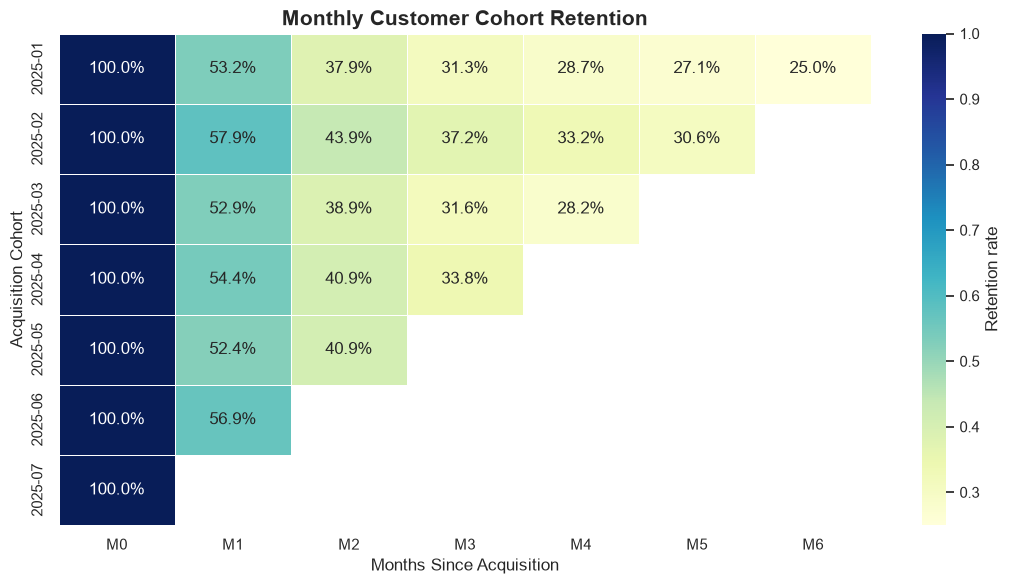

✅ Heatmap saved to: d:\desktop\coding\Topfolio\A-B-Testing-Product-Experimentation-Analysis-M1\findings\figures\03_cohort_retention_heatmap.png


In [5]:
from pathlib import Path

current_dir = Path.cwd()
project_root = (
    current_dir.parent
    if current_dir.name == "notebooks"
    else current_dir
)

figure_dir = project_root / "findings" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

figure_path = figure_dir / "03_cohort_retention_heatmap.png"

plt.figure(figsize=(11, 6))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".1%",
    cmap="YlGnBu",
    linewidths=0.5,
    mask=retention_matrix.isna(),
    cbar_kws={"label": "Retention rate"}
)

plt.title(
    "Monthly Customer Cohort Retention",
    fontsize=15,
    weight="bold"
)
plt.xlabel("Months Since Acquisition")
plt.ylabel("Acquisition Cohort")
plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Heatmap saved to: {figure_path}")

In [6]:
average_retention = retention_matrix.mean()

m1_retention = average_retention["M1"]
m1_drop = 1 - m1_retention

m3_plus_retention = (
    retention_matrix[["M3", "M4", "M5", "M6"]]
    .stack()
    .mean()
)

print(f"Average M1 retention: {m1_retention:.1%}")
print(f"Average M1 drop-off: {m1_drop:.1%}")
print(f"Average observed M3+ retention: {m3_plus_retention:.1%}")

print(
    "\nCurve classification: FLATTENING — "
    "retention falls sharply after acquisition, "
    "then stabilizes among a smaller loyal customer segment."
)

Average M1 retention: 54.6%
Average M1 drop-off: 45.4%
Average observed M3+ retention: 30.7%

Curve classification: FLATTENING — retention falls sharply after acquisition, then stabilizes among a smaller loyal customer segment.


In [7]:
report_path = (
    project_root
    / "findings"
    / "03_retention_dynamics.md"
)

report_word_count = len(
    report_path.read_text(encoding="utf-8").split()
)

assert retention_matrix["M0"].eq(1.0).all()
assert retention_matrix.isna().sum().sum() > 0
assert figure_path.exists()
assert report_path.exists()
assert 300 <= report_word_count <= 500

print("✅ M0 retention is 100% for every cohort")
print("✅ Triangular retention matrix validated")
print("✅ Heatmap file exists")
print(f"✅ Report word count: {report_word_count}")
print("✅ Milestone 3 validation passed")

✅ M0 retention is 100% for every cohort
✅ Triangular retention matrix validated
✅ Heatmap file exists
✅ Report word count: 420
✅ Milestone 3 validation passed
